In [1]:
# ============================================================
# Stacked LSTM for Temperature Forecasting (Optimized)
# ============================================================

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt

plt.style.use('seaborn-v0_8-darkgrid')

# 2. LOAD DATA
df = pd.read_csv('DailyDelhiClimateTrain.csv', parse_dates=['date'], index_col='date')
df = df.ffill()  # forward fill missing values

features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']

# 3. SCALE DATA
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])

target_scaler = MinMaxScaler()
target_scaler.fit(df[['meantemp']])

# 4. CREATE SEQUENCES (time-series window)
def create_sequences(data, lookback=30):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

LOOKBACK = 30
X, y = create_sequences(scaled_data, LOOKBACK)

# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [2]:

# ============================================================
# 5. BASELINE STACKED LSTM
# ============================================================
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, len(features))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=Adam(0.001), loss='mae')

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)


Epoch 1/50


c:\Users\Harshita\Desktop\ML-DL lab\venv-dl\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1988 - val_loss: 0.0593
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0976 - val_loss: 0.0582
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0902 - val_loss: 0.0563
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0896 - val_loss: 0.0627
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0894 - val_loss: 0.0670
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0858 - val_loss: 0.0557
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0834 - val_loss: 0.0519
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0832 - val_loss: 0.0738
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0788 - val_loss: 0.0583
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0777 - val_loss: 0.0619
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0789 - val_loss: 0.0520
Epoch 12/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0776 - val_l

In [3]:

# ============================================================
# 6. EVALUATION
# ============================================================
y_pred = model.predict(X_test)

y_pred_actual = target_scaler.inverse_transform(y_pred)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1,1))

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"\nBaseline LSTM → RMSE:{rmse:.2f}, MAE:{mae:.2f}, R2:{r2:.2f}")


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Baseline LSTM → RMSE:2.22, MAE:1.75, R2:0.85


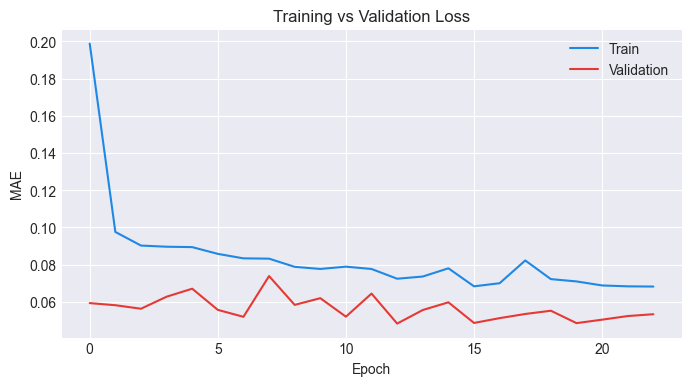

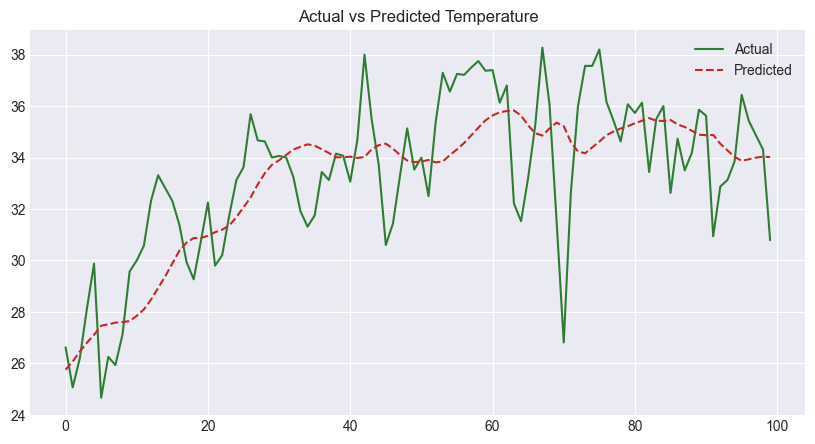

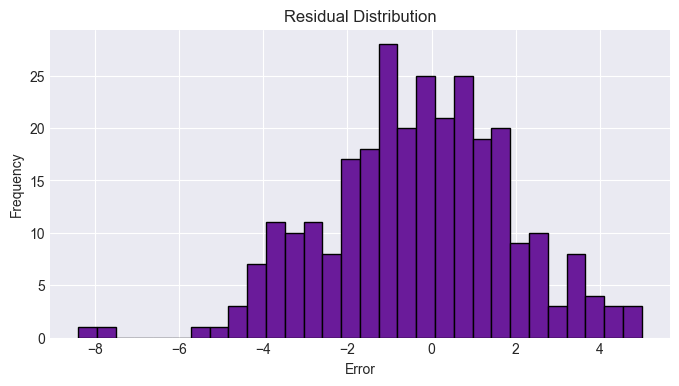

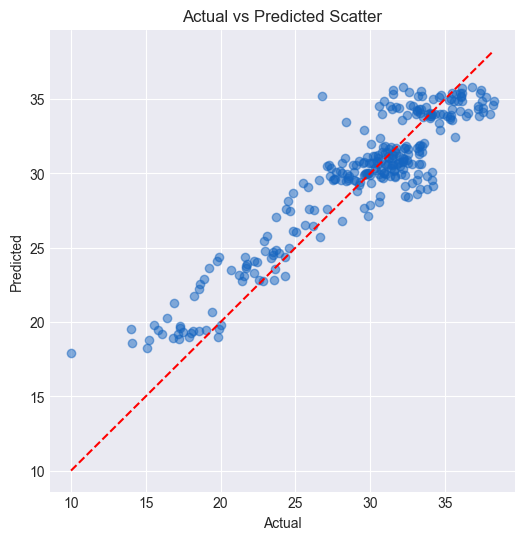

In [4]:

# ============================================================
# 7. VISUALIZATIONS (IMPORTANT + CLEAN)
# ============================================================

# (1) Loss Curve → Overfitting check
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train', color='#1E88E5')
plt.plot(history.history['val_loss'], label='Validation', color='#E53935')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

# (2) Actual vs Predicted → Main result
plt.figure(figsize=(10,5))
plt.plot(y_test_actual[:100], label='Actual', color='#2E7D32')
plt.plot(y_pred_actual[:100], label='Predicted', color='#C62828', linestyle='--')
plt.title("Actual vs Predicted Temperature")
plt.legend()
plt.show()

# (3) Residual Histogram → Error distribution
residuals = y_test_actual - y_pred_actual
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=30, color='#6A1B9A', edgecolor='black')
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

# (4) Scatter Plot → Prediction quality
plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5, color='#1565C0')
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()], 'r--')
plt.title("Actual vs Predicted Scatter")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


In [5]:

# ============================================================
# 8. HYPERPARAMETER TUNING (MANDATORY)
# ============================================================

def build_model(hp):
    model = Sequential()

    # Tune first LSTM
    units1 = hp.Int('units1', 32, 128, step=32)
    model.add(LSTM(units1, return_sequences=True, input_shape=(LOOKBACK, len(features))))

    # Tune dropout
    dropout1 = hp.Float('dropout1', 0.1, 0.5, step=0.1)
    model.add(Dropout(dropout1))

    # Tune second LSTM
    units2 = hp.Int('units2', 16, 64, step=16)
    model.add(LSTM(units2))

    dropout2 = hp.Float('dropout2', 0.1, 0.4, step=0.1)
    model.add(Dropout(dropout2))

    model.add(Dense(1))

    lr = hp.Choice('lr', [1e-2, 1e-3, 1e-4])
    model.compile(optimizer=Adam(lr), loss='mae')

    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,   # keep small for laptop
    directory='lstm_tuner',
    project_name='temp_forecast'
)

tuner.search(
    X_train, y_train,
    epochs=30,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5)],
    shuffle=False,
    verbose=1
)

best_model = tuner.get_best_models(1)[0]

# Evaluate tuned model
y_pred_tuned = best_model.predict(X_test)
y_pred_tuned_actual = target_scaler.inverse_transform(y_pred_tuned)

rmse_t = np.sqrt(mean_squared_error(y_test_actual, y_pred_tuned_actual))
mae_t = mean_absolute_error(y_test_actual, y_pred_tuned_actual)
r2_t = r2_score(y_test_actual, y_pred_tuned_actual)

print(f"\nTuned LSTM → RMSE:{rmse_t:.2f}, MAE:{mae_t:.2f}, R2:{r2_t:.2f}")

Trial 5 Complete [00h 00m 05s]
val_loss: 0.047666266560554504

Best val_loss So Far: 0.04540112987160683
Total elapsed time: 00h 01m 02s
1/9 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step

c:\Users\Harshita\Desktop\ML-DL lab\venv-dl\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Tuned LSTM → RMSE:2.20, MAE:1.71, R2:0.85
